How to store it?
Since all steps are independent and we have a list of paths, we could of paths = listof(listof(ordered_steps)), but a list of a list is matrix, hence, lets use numpy arrays

In [1]:
import matplotlib.pyplot as plt
import numpy as np

Now, lets not do it sequentially, numpy can vectorize it, we can vectorize through the steps or through the paths, lets do through the steps, that feels natural, we could want to calculate steps differently but paths are always there

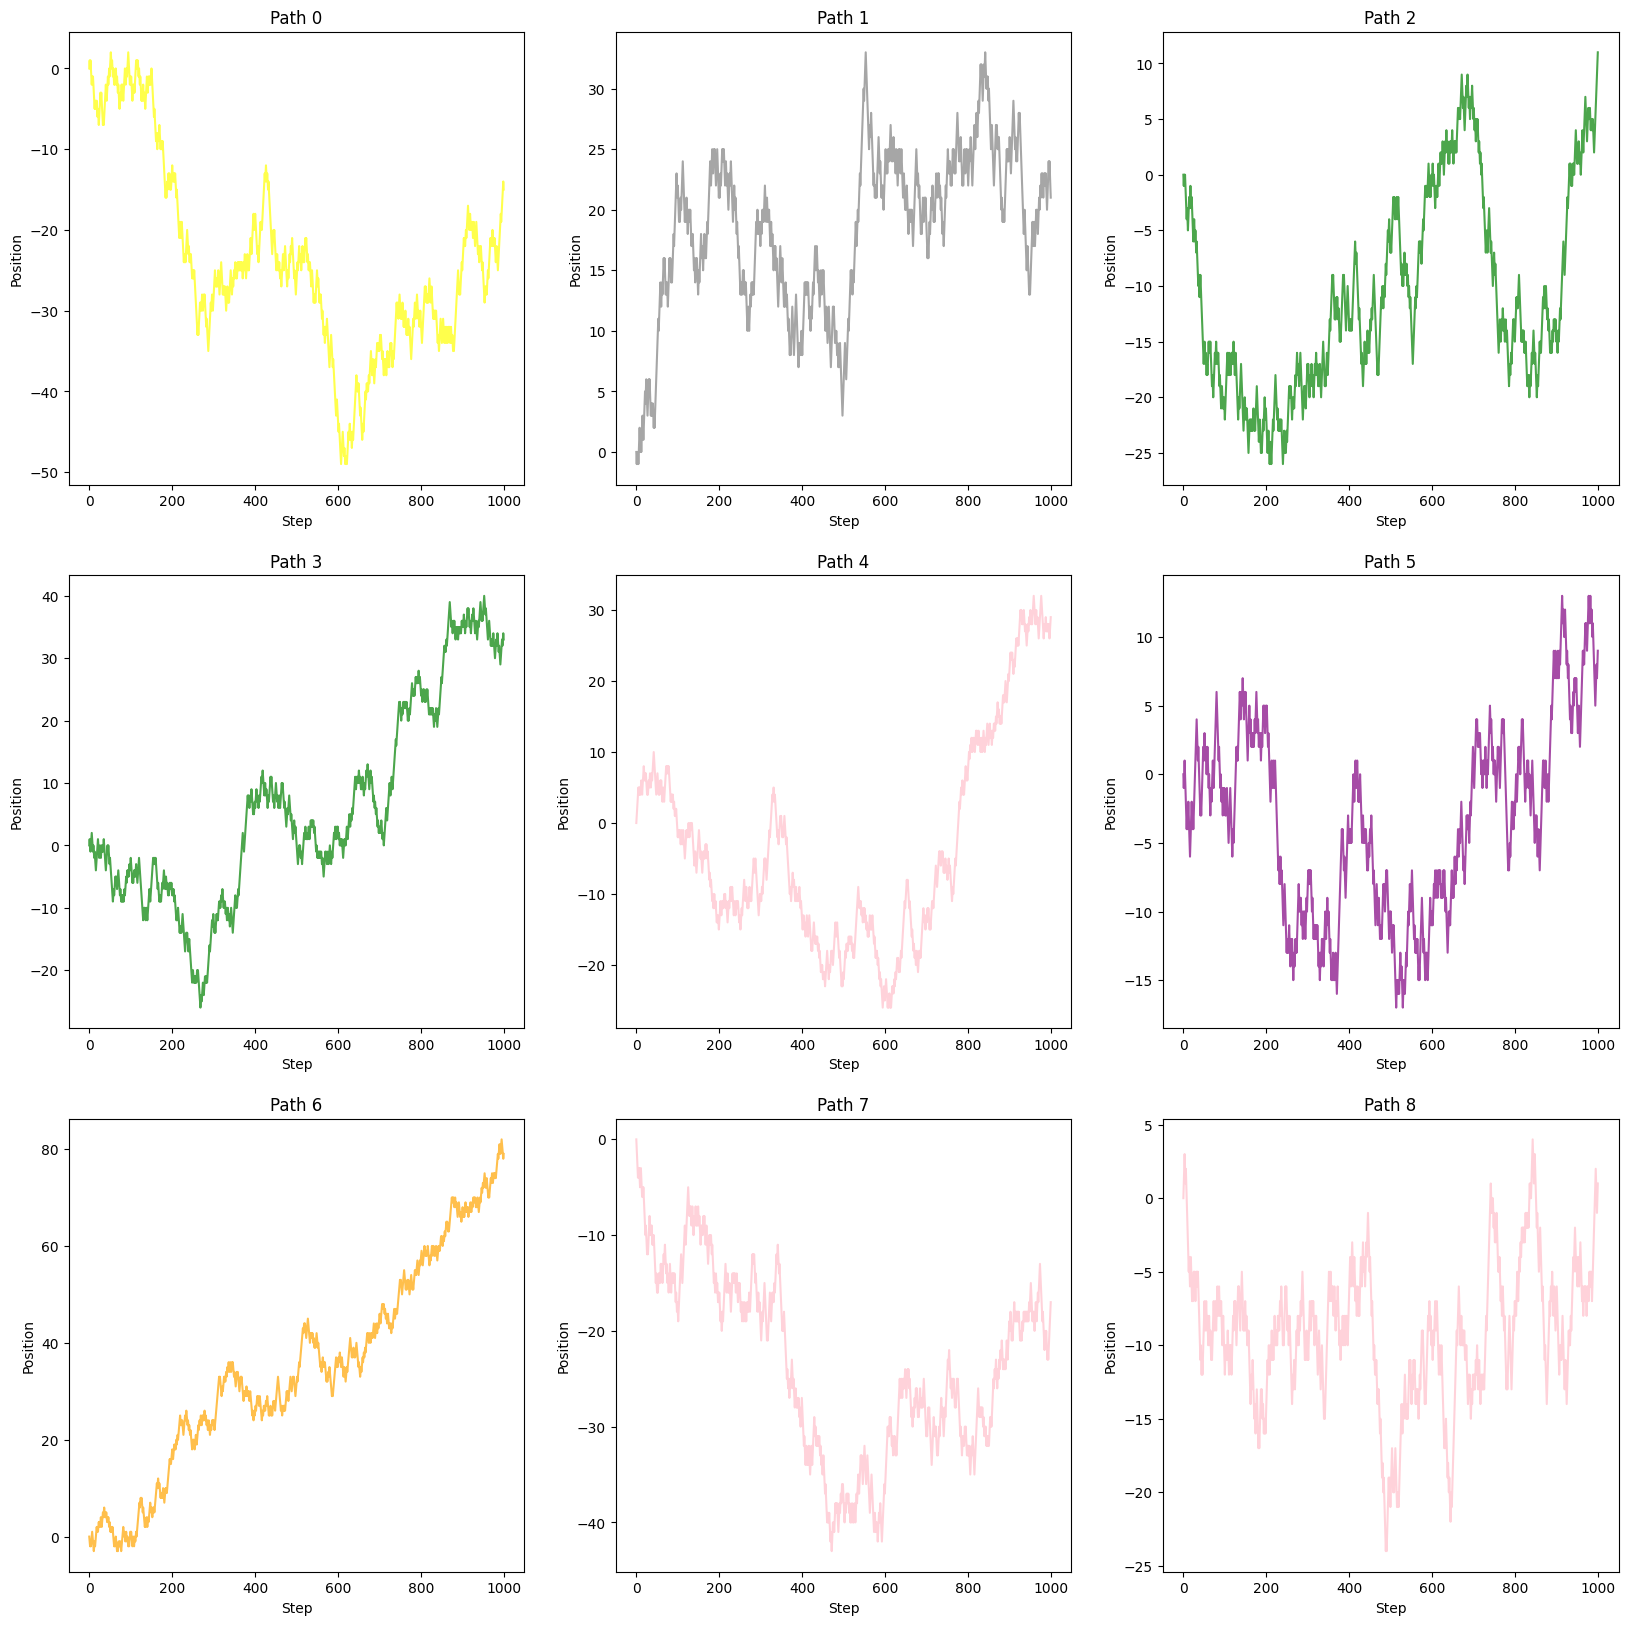

In [2]:

n_paths = 1000
steps = 1000
trajectories = np.zeros((n_paths, steps))
generator = np.random.default_rng(18)

for step in range(steps - 1): # we start  on the second step, so, we need one less step
    time_step = step + 1
    trajectories[:, time_step] = trajectories[:, time_step- 1] + generator.choice([-1, 1], size=n_paths)

fig, axes = plt.subplots(3, 3, figsize=(20, 20))
step_axis = np.linspace(0, steps, steps)

colors = ['blue', 'red', 'green', 'black', 'yellow', 'purple', 'orange', 'brown', 'pink', 'gray']
for index, tracjectory in enumerate(trajectories[:9]):
    row = index // 3
    column = index % 3
    color = np.random.choice(colors)
    ax = axes[row, column]
    ax.plot(step_axis, tracjectory, color=color, alpha=0.7)
    ax.set_title(f"Path {index}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Position")

plt.show()

Cool, now lets do it in 2d.

Well, for 2d, we need a new dimension for the computation, we can make it a 2d matrix.

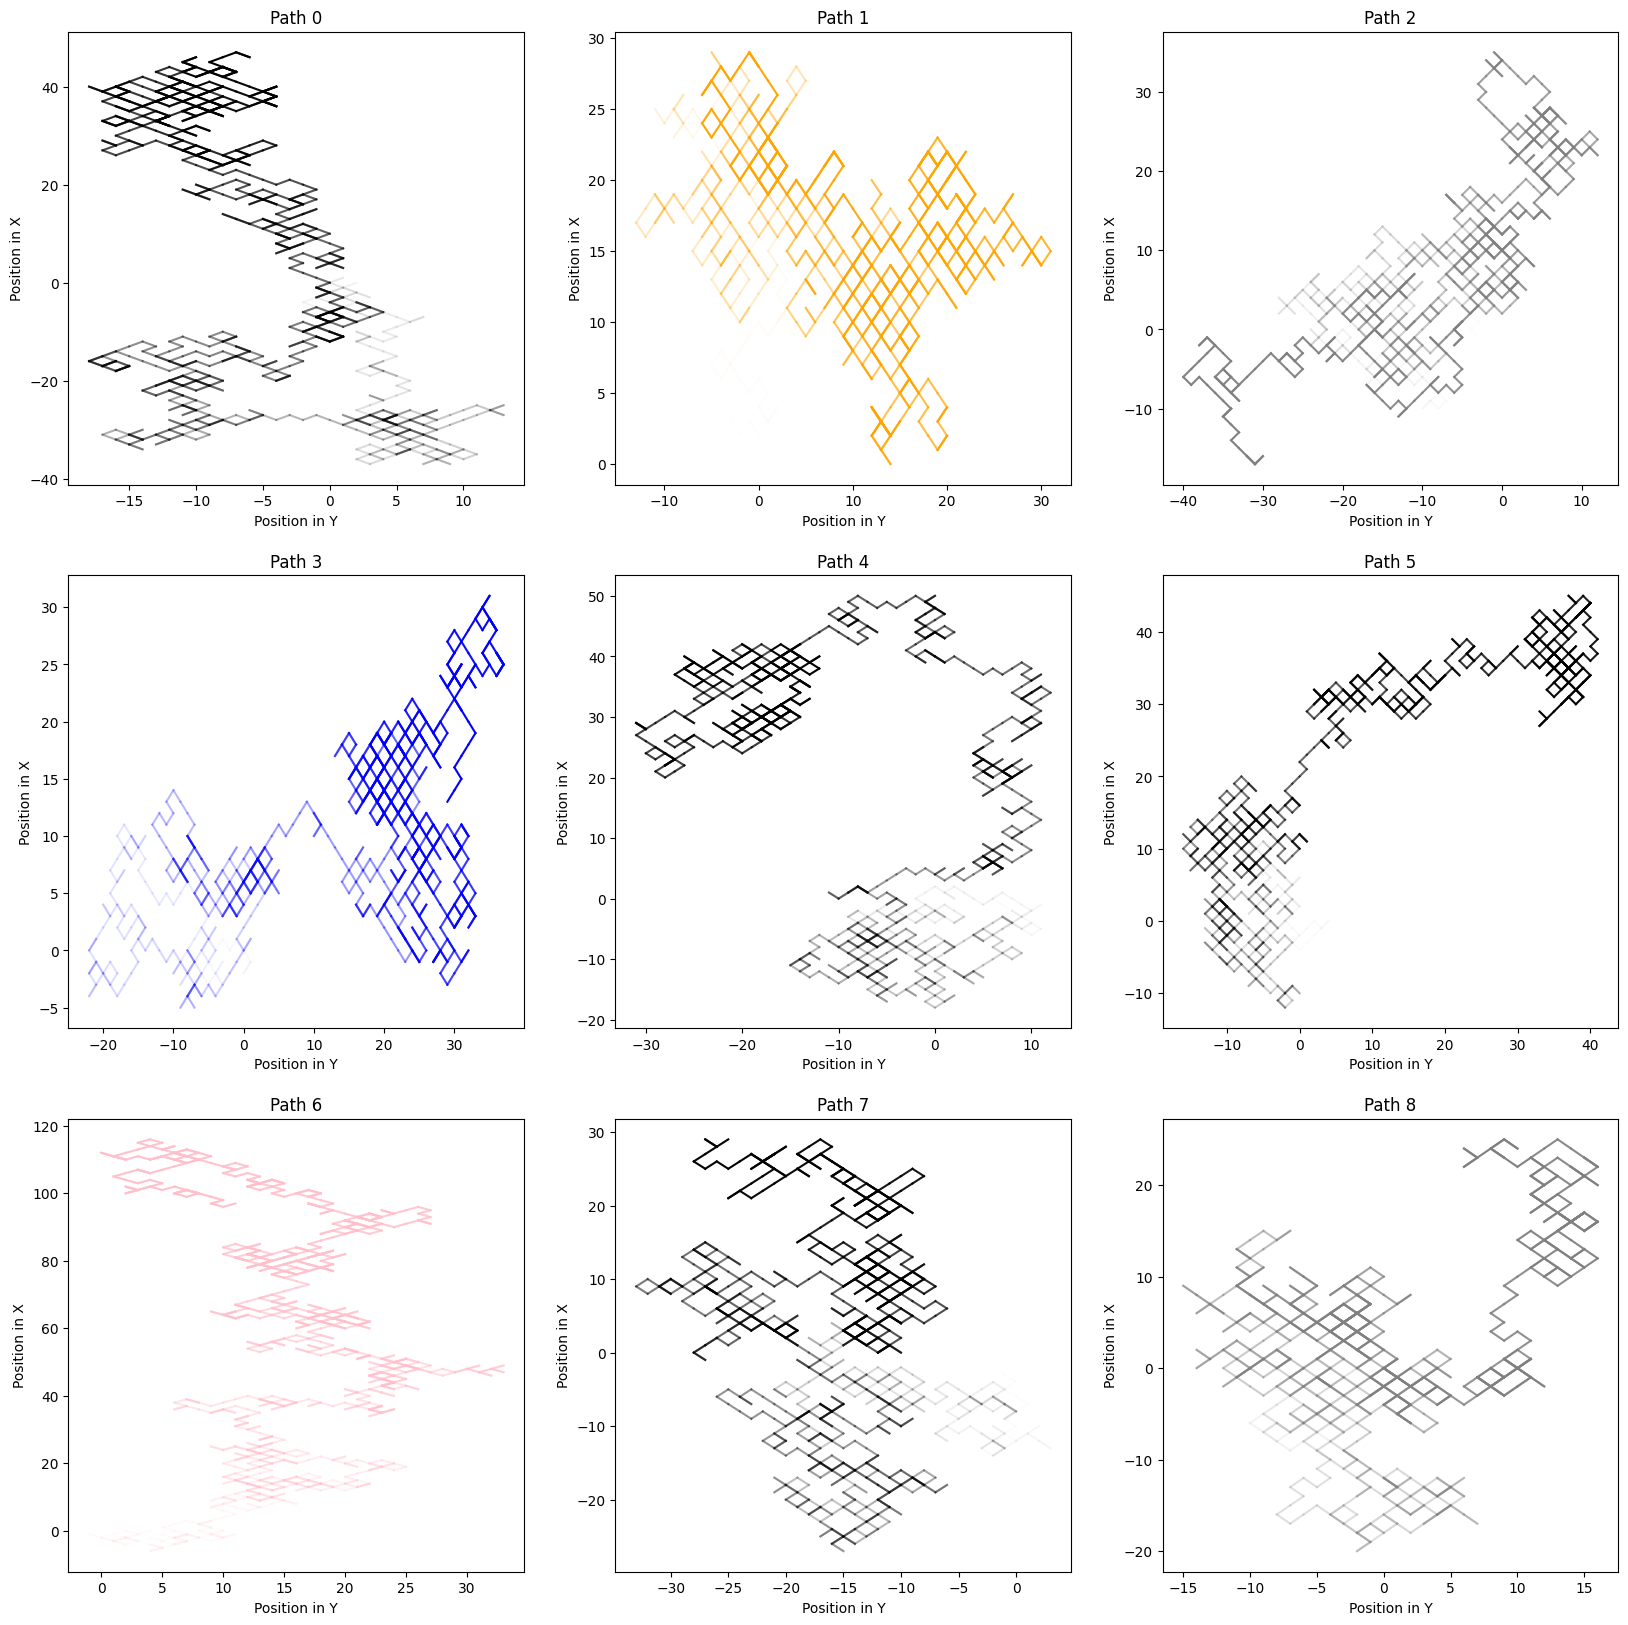

In [3]:
n_dimensions = 2
n_paths = 1000
steps = 1000
trajectories = np.zeros((n_dimensions, n_paths, steps))
generator = np.random.default_rng(18)

for step in range(steps - 1): # we start  on the second step, so, we need one less step
    time_step = step + 1
    trajectories[:, :, time_step] = trajectories[:, :, time_step- 1] + generator.choice([-1, 1], size=(n_dimensions, n_paths))

fig, axes = plt.subplots(3, 3, figsize=(20, 20))
colors = ['blue', 'red', 'green', 'black', 'purple', 'orange', 'brown', 'pink', 'gray']

for index, trajectory in enumerate(range(0, 9)):
    row = index // 3
    column = index % 3
    color = np.random.choice(colors)
    ax = axes[row, column]

    x_axis = trajectories[0, index, :]
    y_axis = trajectories[1, index, :]
    for i in range(steps - 1):
        alpha = (i / steps)
        i = i+1        
        ax.plot([x_axis[i-1], x_axis[i]], [y_axis[i-1], y_axis[i]], color=color, alpha=alpha)
    ax.set_title(f"Path {index}")
    ax.set_xlabel("Position in Y")
    ax.set_ylabel("Position in X")

plt.show()

Can we see stock market?

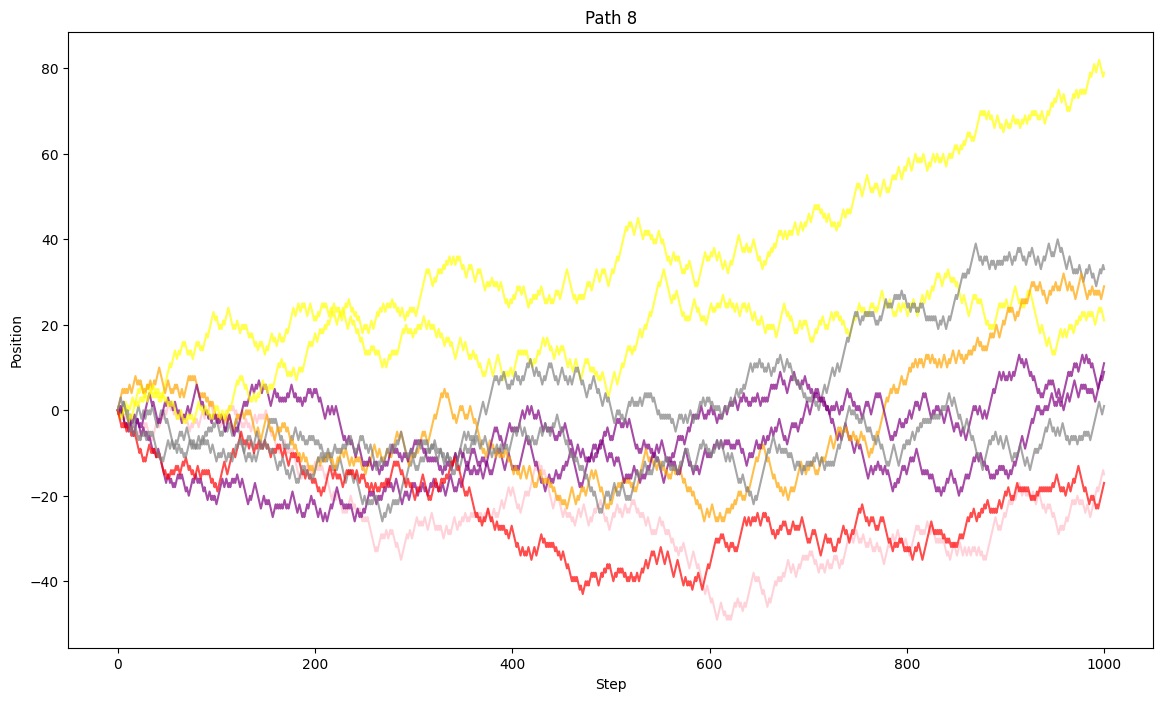

In [4]:

n_paths = 1000
steps = 1000
trajectories = np.zeros((n_paths, steps))
generator = np.random.default_rng(18)

for step in range(steps - 1): # we start  on the second step, so, we need one less step
    time_step = step + 1
    trajectories[:, time_step] = trajectories[:, time_step- 1] + generator.choice([-1, 1], size=n_paths)

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
step_axis = np.linspace(0, steps, steps)

colors = ['blue', 'red', 'green', 'black', 'yellow', 'purple', 'orange', 'brown', 'pink', 'gray']
for index, tracjectory in enumerate(trajectories[:9]):
    color = np.random.choice(colors)
    ax.plot(step_axis, tracjectory, color=color, alpha=0.7)
    ax.set_title(f"Path {index}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Position")

plt.show()


Lets test different generators

0 0 {'loc': 0.0, 'scale': 1.0}
Axes(0.125,0.798085;0.352273x0.0819149)
0 1 {'loc': 0.0, 'scale': 3.0}
Axes(0.547727,0.798085;0.352273x0.0819149)
1 0 {'a': [-1, 1]}
Axes(0.125,0.699787;0.352273x0.0819149)
1 1 {'a': [-1, 1]}
Axes(0.547727,0.699787;0.352273x0.0819149)
2 0 {'low': 0.0, 'high': 1.0}
Axes(0.125,0.601489;0.352273x0.0819149)
2 1 {'low': 2.0, 'high': 3.0}
Axes(0.547727,0.601489;0.352273x0.0819149)
3 0 {'n': 1, 'p': 0.5}
Axes(0.125,0.503191;0.352273x0.0819149)
3 1 {'n': 3, 'p': 0.8}
Axes(0.547727,0.503191;0.352273x0.0819149)
4 0 {'lam': 1.0}
Axes(0.125,0.404894;0.352273x0.0819149)
4 1 {'lam': 1.9}
Axes(0.547727,0.404894;0.352273x0.0819149)
5 0 {'scale': 1.0}
Axes(0.125,0.306596;0.352273x0.0819149)
5 1 {'scale': 2.0}
Axes(0.547727,0.306596;0.352273x0.0819149)
6 0 {'a': 1.0, 'b': 1.0}
Axes(0.125,0.208298;0.352273x0.0819149)
6 1 {'a': 2.0, 'b': 2.0}
Axes(0.547727,0.208298;0.352273x0.0819149)
7 0 {'shape': 1.0, 'scale': 1.0}
Axes(0.125,0.11;0.352273x0.0819149)
7 1 {'shape': 2.0, 'sc

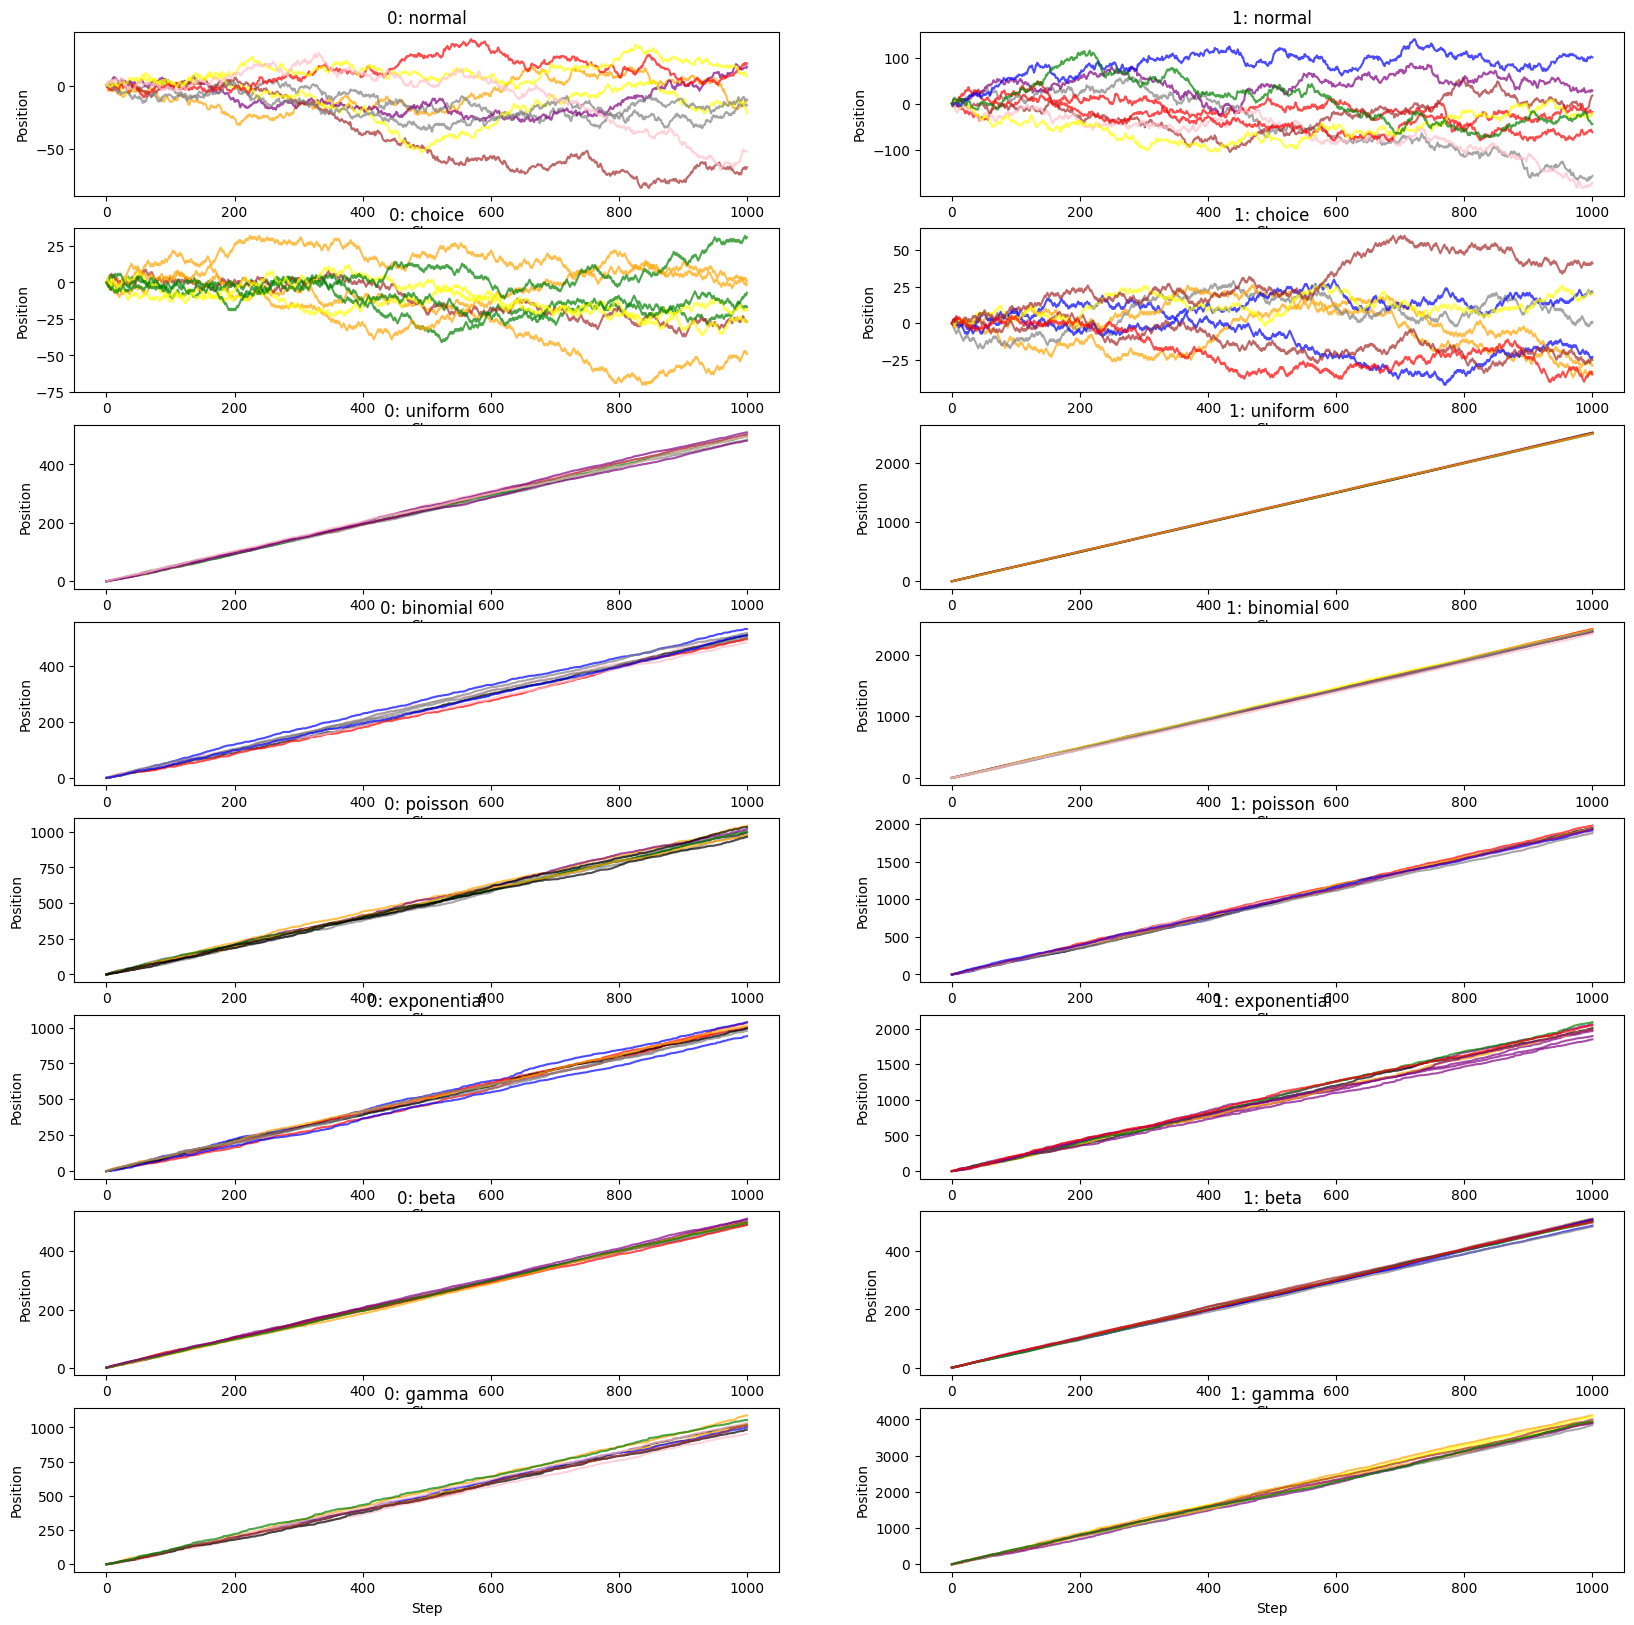

In [22]:

n_paths = 1000
steps = 1000
trajectories = np.zeros((n_paths, steps))
generator = np.random.default_rng(18)

""" 
    Normal: generator.normal(loc=0.0, scale=1.0, size=None)
    Uniform: generator.uniform(low=0.0, high=1.0, size=None)
    Binomial: generator.binomial(n, p, size=None)
    Poisson: generator.poisson(lam=1.0, size=None)
    Exponential: generator.exponential(scale=1.0, size=None)
    Beta: generator.beta(a, b, size=None)
    Gamma: generator.gamma(shape, scale=1.0, size=None)
    Choice (categorical): generator.choice(a, size=None, replace=True, p=None)
"""

generators = {
    generator.normal: [{'loc': 0.0, 'scale': 1.0}, {'loc': 0.0, 'scale': 3.0}],
    generator.choice: [{'a': [-1, 1]}, {'a': [-1, 1]}],
    generator.uniform: [{'low': 0.0, 'high': 1.0}, {'low': 2.0, 'high':3.0}],
    generator.binomial: [{'n': 1, 'p': 0.5}, {'n': 3, 'p': 0.8}],
    generator.poisson: [{'lam': 1.0}, {'lam': 1.9}],
    generator.exponential: [{'scale': 1.0}, {'scale': 2.0}],
    generator.beta: [{'a': 1.0, 'b': 1.0}, {'a': 2.0, 'b': 2.0}],
    generator.gamma: [{'shape': 1.0, 'scale': 1.0}, {'shape': 2.0, 'scale': 2.0}],
}
fig, axes = plt.subplots(8, 2, figsize=(20, 20))
colors = ['blue', 'red', 'green', 'black', 'yellow', 'purple', 'orange', 'brown', 'pink', 'gray']

i = -1
for generator_func, generator_params in generators.items():
    i+=1
    row = axes[i]
    
    for index, params in enumerate(generator_params):
        ax = row[index]
        ax.set_title(f"{index}: {generator_func.__name__}")
        ax.set_xlabel("Step")
        ax.set_ylabel("Position")
        
        print(i, index, params)
        print(ax)
        params['size'] = n_paths

        trajectories = np.zeros((n_paths, steps))
        for step in range(steps - 1): # we start  on the second step, so, we need one less step
            time_step = step + 1
            trajectories[:, time_step] = trajectories[:, time_step- 1] + generator_func(**params)

        step_axis = np.linspace(0, steps, steps)
        colors = ['blue', 'red', 'green', 'black', 'yellow', 'purple', 'orange', 'brown', 'pink', 'gray']
        for index, tracjectory in enumerate(trajectories[:9]):
            color = np.random.choice(colors)
            ax.plot(step_axis, tracjectory, color=color, alpha=0.7)
        

plt.show()

